<a href="https://colab.research.google.com/github/lorramrj/AI-Fundamentals/blob/main/10_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Regressão Linear

A regressão linear é um dos algoritmos de aprendizado de máquina mais fundamentais e amplamente utilizados. Seu objetivo principal é modelar a relação entre uma ou mais variáveis de entrada (independentes) e uma variável de saída (dependente) contínua.

### 1. Definição Formal

Matematicamente, a regressão linear **tenta encontrar a melhor linha (ou hiperplano, em dimensões superiores)** que descreve a relação entre as variáveis.

**Para uma Regressão Linear Simples** (com uma única variável independente $X$ e uma variável dependente $Y$), o modelo pode ser expresso como:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

Onde:
- $Y$: Variável dependente (o que queremos prever).
- $X$: Variável independente (a característica usada para prever $Y$).
- $\beta_0$: Coeficiente de interceptação (o valor esperado de $Y$ quando $X=0$).
- $\beta_1$: Coeficiente angular (a mudança média em $Y$ para cada unidade de mudança em $X$).
- $\epsilon$: Termo de erro irredutível (representa o ruído ou variabilidade não explicada pelo modelo).

O objetivo é estimar os coeficientes $\beta_0$ e $\beta_1$ que minimizem a soma dos quadrados dos resíduos (SQRes), ou seja, a diferença entre os valores observados de $Y$ e os valores previstos pelo modelo ($\hat{Y}$). Este método é conhecido como **Mínimos Quadrados Ordinários (MQO)**.

**Para uma Regressão Linear Múltipla** (com múltiplas variáveis independentes $X_1, X_2, ..., X_n$), o modelo é generalizado para:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n + \epsilon$$

Onde cada $\beta_i$ representa o impacto da variável $X_i$ em $Y$, mantendo todas as outras variáveis constantes.

### 2. Tipos de Regressão Linear

Embora a base seja a mesma, a regressão linear pode ser categorizada de diferentes formas:

*   **Regressão Linear Simples**: Envolve apenas uma variável independente para prever a variável dependente.
    *   Exemplo: Prever o preço de uma casa com base apenas em sua área.

*   **Regressão Linear Múltipla**: Envolve duas ou mais variáveis independentes para prever a variável dependente.
    *   Exemplo: Prever o preço de uma casa com base em sua área, número de quartos e localização.

*   **Regressão Polinomial**: Embora ainda seja considerada uma forma de regressão linear (porque é linear nos coeficientes), ela modela a relação entre as variáveis de forma não linear, adicionando termos polinomiais (quadrático, cúbico, etc.) às variáveis independentes. Isso permite capturar curvas nos dados.
    *   Exemplo: $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon$

*   **Regressão Linear Múltipla com Interações**: Inclui termos de interação entre variáveis independentes, o que significa que o efeito de uma variável em $Y$ pode depender do valor de outra variável.
    *   Exemplo: $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 + \epsilon$

Outras variações incluem a **Regressão Ridge**, **Lasso** e **Elastic Net**, que são métodos de regularização usados para lidar com multicolinearidade e evitar overfitting, adicionando penalidades aos coeficientes.

### 3. Python e Bibliotecas Essenciais

Para implementar a regressão linear em Python, você utilizará principalmente as seguintes bibliotecas:

*   **`numpy`**: Para operações numéricas e criação de arrays.
*   **`pandas`**: Para manipulação e análise de dados (DataFrames).
*   **`matplotlib.pyplot`** e **`seaborn`**: Para visualização de dados e resultados do modelo.
*   **`scikit-learn`**: A biblioteca padrão para machine learning em Python, que contém implementações eficientes de modelos de regressão linear e ferramentas para pré-processamento, seleção de modelos e avaliação.
*   **`statsmodels`**: Para uma análise estatística mais profunda, com saídas detalhadas de testes de hipóteses, p-valores, etc., que são cruciais para inferência estatística.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Configurações para visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

### 4. Exemplo Prático: Regressão Linear Simples

Vamos gerar alguns dados sintéticos e aplicar um modelo de regressão linear simples para prever um valor com base em uma única característica.

,X,y
0,0.749080,6.334288
1,1.901429,9.405278
2,1.463988,8.483724
3,1.197317,5.604382
4,0.312037,4.716440


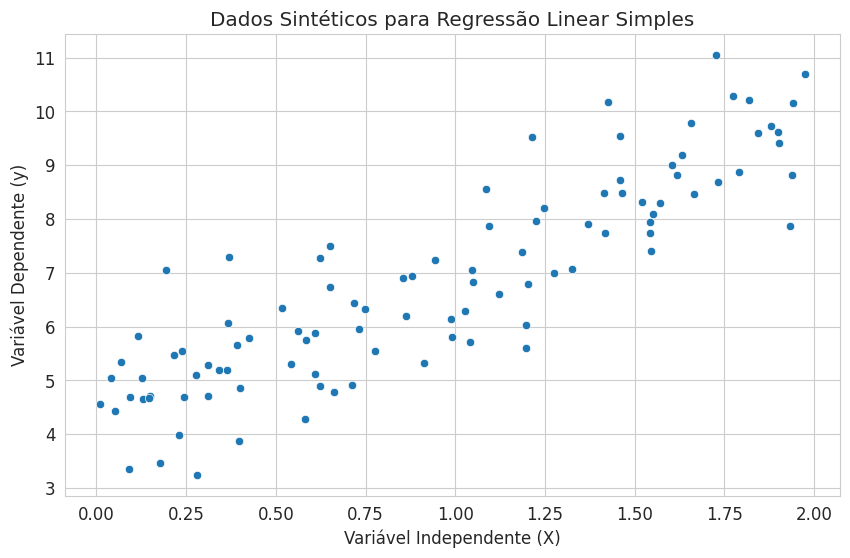

In [20]:
# Gerando dados sintéticos
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 amostras, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + ruído

# Criando um DataFrame para facilitar a visualização
df_simple = pd.DataFrame({'X': X.flatten(), 'y': y.flatten()})
display(df_simple.head())

# Plotando os dados
plt.figure(figsize=(10, 6))
sns.scatterplot(x='X', y='y', data=df_simple)
plt.title('Dados Sintéticos para Regressão Linear Simples')
plt.xlabel('Variável Independente (X)')
plt.ylabel('Variável Dependente (y)')
plt.show()

#### Treinamento do Modelo (Scikit-learn)

Vamos dividir os dados em conjuntos de treinamento e teste, treinar o modelo e avaliar seu desempenho.

In [21]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando o modelo de Regressão Linear
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred_simple = model_simple.predict(X_test)

# Exibindo os coeficientes
print(f"Coeficiente (beta_1): {model_simple.coef_[0][0]:.2f}")
print(f"Intercepto (beta_0): {model_simple.intercept_[0]:.2f}")

# Avaliando o modelo
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print(f"Erro Quadrático Médio (MSE): {mse_simple:.2f}")
print(f"R-quadrado: {r2_simple:.2f}")

Coeficiente (beta_1): 2.80
Intercepto (beta_0): 4.14
Erro Quadrático Médio (MSE): 0.65
R-quadrado: 0.81


#### Visualização da Linha de Regressão

É crucial visualizar a linha de regressão ajustada sobre os pontos de dados.

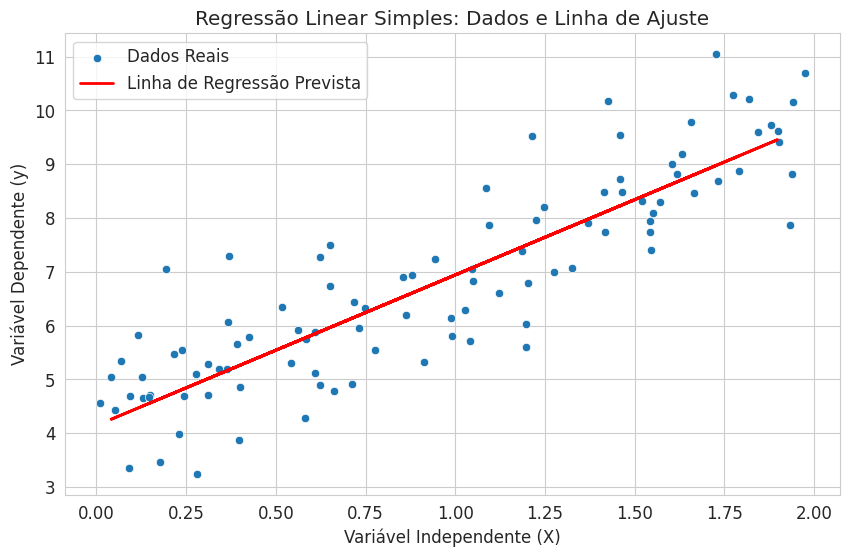

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='X', y='y', data=df_simple, label='Dados Reais')
plt.plot(X_test, y_pred_simple, color='red', linewidth=2, label='Linha de Regressão Prevista')
plt.title('Regressão Linear Simples: Dados e Linha de Ajuste')
plt.xlabel('Variável Independente (X)')
plt.ylabel('Variável Dependente (y)')
plt.legend()
plt.show()

#### Análise Estatística Detalhada (Statsmodels)

Para uma visão mais estatística, o `statsmodels` oferece um relatório completo.

In [23]:
X_sm = sm.add_constant(X) # Adiciona um intercepto (constante) ao X para statsmodels
model_sm = sm.OLS(y, X_sm) # OLS = Ordinary Least Squares
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     326.7
Date:                Wed, 13 May 2026   Prob (F-statistic):           5.66e-33
Time:                        22:43:10   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2151      0.170     24.753      0.0

### 5. Exemplo Prático: Regressão Linear Múltipla

Agora, vamos considerar um cenário com múltiplas variáveis independentes.

In [24]:
# Gerando dados sintéticos para Regressão Múltipla
np.random.seed(42)
X_multi = np.random.rand(100, 3) # 100 amostras, 3 features
y_multi = 2 + 1.5 * X_multi[:,0] + 0.5 * X_multi[:,1] - 1 * X_multi[:,2] + np.random.randn(100) * 0.5

df_multi = pd.DataFrame(X_multi, columns=['Feature_1', 'Feature_2', 'Feature_3'])
df_multi['Target'] = y_multi
display(df_multi.head())

# Dividindo os dados
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Treinando o modelo
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

# Fazendo previsões
y_pred_multi = model_multi.predict(X_test_multi)

# Exibindo os coeficientes
print("Coeficientes:")
for i, coef in enumerate(model_multi.coef_):
    print(f"  Beta_{i+1}: {coef:.2f}")
print(f"Intercepto (beta_0): {model_multi.intercept_:.2f}")

# Avaliando o modelo
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print(f"\nErro Quadrático Médio (MSE): {mse_multi:.2f}")
print(f"R-quadrado: {r2_multi:.2f}")

,Feature_1,Feature_2,Feature_3,Target
0,0.374540,0.950714,0.731994,2.327959
1,0.598658,0.156019,0.155995,2.494202
2,0.058084,0.866176,0.601115,2.991071
3,0.708073,0.020584,0.969910,2.419451
4,0.832443,0.212339,0.181825,2.160437


Coeficientes:
  Beta_1: 1.55
  Beta_2: 0.46
  Beta_3: -0.66
Intercepto (beta_0): 1.96

Erro Quadrático Médio (MSE): 0.50
R-quadrado: 0.28


### 6. Gráficos e Visualizações Importantes

Além dos gráficos básicos, outras visualizações são cruciais para entender seu modelo:

*   **Gráfico de Resíduos**: Plota os resíduos (erros de previsão) versus os valores previstos ou as variáveis independentes. O ideal é que os resíduos sejam distribuídos aleatoriamente em torno de zero, sem padrões claros (indicando que o modelo capturou bem a relação). Um padrão nos resíduos sugere que o modelo não está ajustado corretamente (ex: relação não linear não capturada).

*   **Gráfico de Previsões vs. Reais**: Plota os valores previstos pelo modelo versus os valores reais. Idealmente, os pontos devem se alinhar em uma linha diagonal de 45 graus, indicando previsões precisas.

*   **Histograma dos Resíduos**: Mostra a distribuição dos resíduos. Para um bom modelo de regressão linear, os resíduos devem ter uma distribuição aproximadamente normal, com média zero. Isso é uma das premissas da regressão linear.

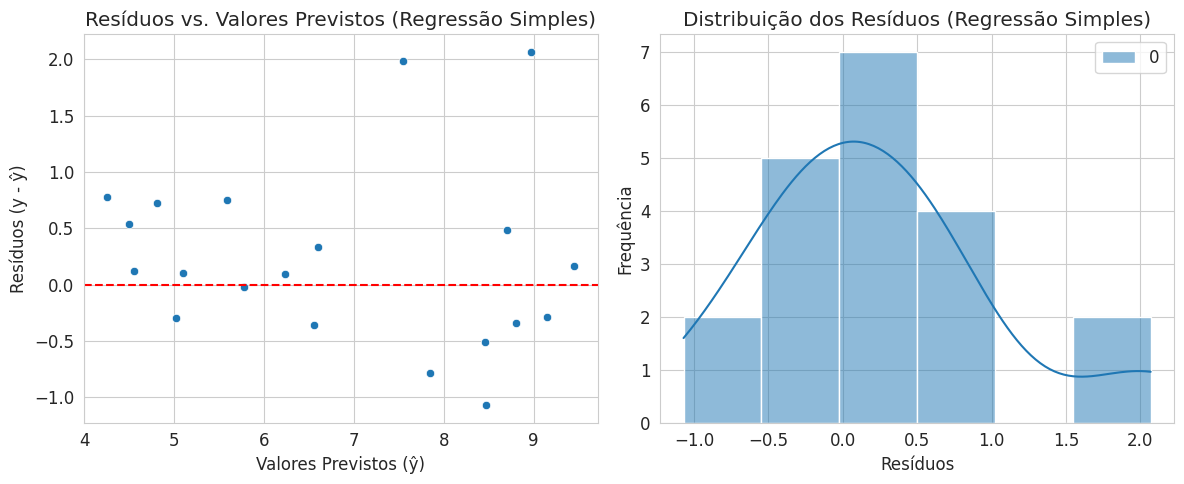

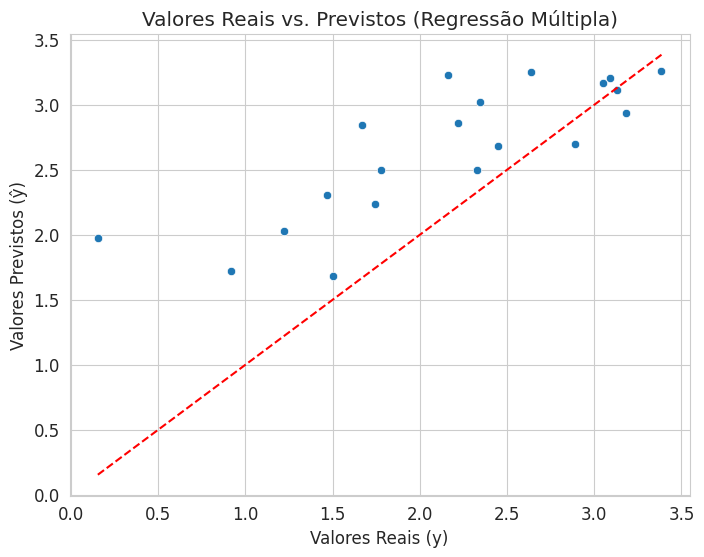

In [25]:
# Gráfico de Resíduos para o modelo simples
residuals_simple = y_test - y_pred_simple

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Gráfico de Resíduos vs Previsões
sns.scatterplot(x=y_pred_simple.flatten(), y=residuals_simple.flatten())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos vs. Valores Previstos (Regressão Simples)')
plt.xlabel('Valores Previstos (ŷ)')
plt.ylabel('Resíduos (y - ŷ)')

plt.subplot(1, 2, 2) # Histograma dos Resíduos
sns.histplot(residuals_simple, kde=True)
plt.title('Distribuição dos Resíduos (Regressão Simples)')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

# Gráfico de Previsões vs. Reais para o modelo múltiplo
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_multi, y=y_pred_multi)
plt.plot([min(y_test_multi), max(y_test_multi)], [min(y_test_multi), max(y_test_multi)], color='red', linestyle='--') # Linha de 45 graus
plt.title('Valores Reais vs. Previstos (Regressão Múltipla)')
plt.xlabel('Valores Reais (y)')
plt.ylabel('Valores Previstos (ŷ)')
plt.show()

### 7. Macetes (Dicas e Truques) para Ser um Expert

Para realmente dominar a regressão linear, preste atenção a estes pontos:

1.  **Premissas da Regressão Linear**: A regressão linear tem algumas premissas importantes que, se violadas, podem invalidar seus resultados. Aprenda sobre elas:
    *   **Linearidade**: A relação entre as variáveis independentes e dependente é linear.
    *   **Independência dos Resíduos**: Os resíduos são independentes um do outro.
    *   **Homocedasticidade**: A variância dos resíduos é constante em todos os níveis das variáveis independentes (sem padrão de 'funil' nos gráficos de resíduos).
    *   **Normalidade dos Resíduos**: Os resíduos são normalmente distribuídos.
    *   **Ausência de Multicolinearidade**: As variáveis independentes não são altamente correlacionadas entre si (isso é mais para regressão múltipla).

2.  **Multicolinearidade**: Quando duas ou mais variáveis independentes são altamente correlacionadas. Isso pode dificultar a interpretação dos coeficientes e torná-los instáveis. Métodos para detectar e lidar com isso incluem:
    *   **Fator de Inflação de Variância (VIF)**: Um VIF alto (geralmente > 5 ou > 10) indica multicolinearidade.
    *   Remover uma das variáveis correlacionadas ou usar técnicas de regularização como Ridge ou Lasso.

3.  **Outliers e Pontos de Alavancagem**: Observações extremas podem influenciar desproporcionalmente o modelo. Identifique-os usando gráficos de dispersão, gráficos de resíduos ou medidas como a Distância de Cook. Decida se devem ser removidos, transformados ou modelados de forma diferente.

4.  **Engenharia de Features**: A qualidade das suas features é mais importante que o algoritmo em si. Crie novas features a partir das existentes (ex: termos polinomiais, interações, logaritmos) para capturar relações não lineares ou melhorar o poder preditivo.

5.  **Escalonamento de Features**: Embora não seja estritamente necessário para o algoritmo de Mínimos Quadrados (os coeficientes se ajustarão), o escalonamento (padronização ou normalização) é uma boa prática e é crucial para métodos regularizados (Ridge, Lasso) e algoritmos baseados em distância. Facilita a convergência e torna a interpretação dos coeficientes mais comparável.

6.  **Regularização (Ridge, Lasso, Elastic Net)**: Se você tem muitas features, ou features altamente correlacionadas, ou quer evitar overfitting, use regressões regularizadas:
    *   **Ridge**: Adiciona uma penalidade L2 aos coeficientes, encolhendo-os, mas raramente os tornando zero. Útil para reduzir a variância e lidar com multicolinearidade.
    *   **Lasso**: Adiciona uma penalidade L1, que pode encolher coeficientes e até mesmo zerar alguns, realizando seleção de features. Útil quando você suspeita que muitas features são irrelevantes.
    *   **Elastic Net**: Combinação de Ridge e Lasso.

7.  **Interpretação dos Coeficientes**: Lembre-se que um coeficiente de $\beta_i$ significa que, mantendo todas as outras variáveis constantes, um aumento de uma unidade em $X_i$ está associado a um aumento (ou diminuição, se $\beta_i$ for negativo) de $\beta_i$ unidades em $Y$.

8.  **R-quadrado (R²)**: Indica a proporção da variância na variável dependente que é explicada pelo modelo. Um R² de 0.8 significa que 80% da variabilidade de Y é explicada pelas suas features. Cuidado: um R² alto nem sempre significa um bom modelo, e ele sempre aumentará com a adição de mais features, mesmo irrelevantes.

9.  **R-quadrado Ajustado**: É uma versão melhorada do R² que penaliza a adição de features irrelevantes. Use-o para comparar modelos com diferentes números de features.

10. **Validação Cruzada**: Sempre use validação cruzada (ex: K-Fold Cross-Validation) para obter uma estimativa mais robusta do desempenho do seu modelo em dados não vistos, em vez de depender apenas de uma única divisão de treino/teste.

Com esses conceitos e práticas, você estará bem encaminhado para se tornar um expert em regressão linear!

## 8. Recursos Adicionais e Aprofundamento

### 8.1. Regressão Polinomial

A Regressão Polinomial é uma forma de regressão linear que modela a relação entre a variável independente $X$ e a variável dependente $Y$ como um polinômio de $n$-ésimo grau. Embora o modelo pareça não-linear devido aos termos exponenciais da variável independente, ele é *linear nos seus coeficientes*, o que o torna uma variação da regressão linear. Isso permite capturar relações curvas nos dados.

**Forma Geral:**
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + ... + \beta_n X^n + \epsilon$$

Onde $n$ é o grau do polinômio. Um grau $n=1$ é a regressão linear simples. Um grau $n=2$ é uma regressão quadrática, e assim por diante.

**Vantagens:**
*   Pode modelar relações não-lineares.
*   Relativamente simples de implementar.

**Desvantagens:**
*   Alto grau do polinômio pode levar a overfitting (ajuste excessivo aos dados de treinamento, performando mal em dados novos).
*   Interpretabilidade dos coeficientes pode ser mais complexa.

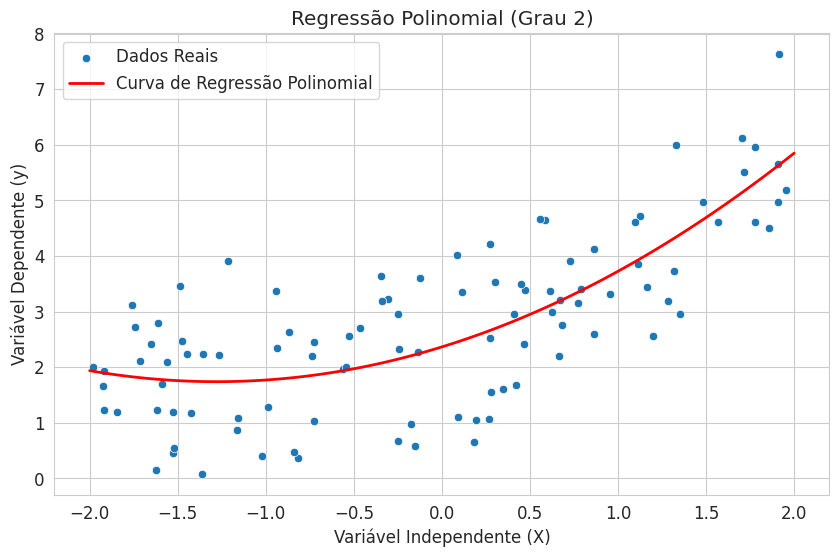

Coeficientes: [0.97814548 0.38223991]
Intercepto: 2.37
MSE (Polinomial): 0.91
R-quadrado (Polinomial): 0.49


In [26]:
from sklearn.preprocessing import PolynomialFeatures

# Gerar dados sintéticos com uma relação quadrática
np.random.seed(0)
X_poly = 2 * np.random.rand(100, 1) * 2 - 2 # Valores entre -2 e 2
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(100, 1) # y = 0.5x^2 + x + 2 + ruído

# Transformar as features em polinômiais (grau 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_transformed = poly_features.fit_transform(X_poly)

# Dividir os dados
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly_transformed, y_poly, test_size=0.2, random_state=42)

# Treinar o modelo de Regressão Linear nos dados transformados
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

# Fazer previsões
y_pred_poly = model_poly.predict(X_test_poly)

# Visualização
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_poly.flatten(), y=y_poly.flatten(), label='Dados Reais')

# Para plotar a linha de regressão, precisamos ordenar os dados X
X_new = np.linspace(-2, 2, 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)
y_new_pred = model_poly.predict(X_new_poly)

plt.plot(X_new, y_new_pred, color='red', linewidth=2, label='Curva de Regressão Polinomial')
plt.title('Regressão Polinomial (Grau 2)')
plt.xlabel('Variável Independente (X)')
plt.ylabel('Variável Dependente (y)')
plt.legend()
plt.show()

mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print(f"Coeficientes: {model_poly.coef_.flatten()}")
print(f"Intercepto: {model_poly.intercept_[0]:.2f}")
print(f"MSE (Polinomial): {mse_poly:.2f}")
print(f"R-quadrado (Polinomial): {r2_poly:.2f}")

### 8.2. Regressão de Ridge e Lasso (Regularização)

**Regularização** é uma técnica usada para evitar o overfitting de modelos de regressão, especialmente quando há muitas variáveis independentes ou quando elas são altamente correlacionadas (multicolinearidade). Ela adiciona uma "penalidade" aos coeficientes do modelo, incentivando-os a serem menores.

#### Regressão Ridge (Penalidade L2)

A Regressão Ridge adiciona uma penalidade L2 (o quadrado da magnitude dos coeficientes) à função de custo (MQO). Isso força os coeficientes a serem pequenos, mas geralmente não os zera completamente.

**Função de Custo:**
$$\text{Minimizar: } \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \beta_j^2$$

Onde:
- $\alpha$ (alfa) é o parâmetro de regularização, controlando a força da penalidade. Um $\alpha$ maior resulta em coeficientes menores.

**Vantagens:**
*   Reduz a variância do modelo, melhorando a generalização.
*   Útil para lidar com multicolinearidade.
*   Mantém todas as features.

**Desvantagens:**
*   Não realiza seleção de features (não zera coeficientes).

#### Regressão Lasso (Penalidade L1)

A Regressão Lasso (Least Absolute Shrinkage and Selection Operator) adiciona uma penalidade L1 (o valor absoluto da magnitude dos coeficientes) à função de custo. Ao contrário do Ridge, o Lasso tem a capacidade de zerar coeficientes de features menos importantes, realizando, assim, a **seleção automática de features**.

**Função de Custo:**
$$\text{Minimizar: } \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |\beta_j|$$

**Vantagens:**
*   Realiza seleção de features, resultando em modelos mais esparsos e interpretáveis.
*   Reduz a variância e melhora a generalização.

**Desvantagens:**
*   Pode ser instável na seleção de features se houver grupos de features altamente correlacionadas.

#### Elastic Net (Combinação L1 e L2)

Elastic Net combina as penalidades L1 e L2, herdando as vantagens de ambas: seleção de features e agrupamento de variáveis correlacionadas.

In [27]:
from sklearn.linear_model import Ridge, Lasso

# Usaremos os dados de regressão linear múltipla (X_multi, y_multi)

# Dividir os dados para regularização
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# --- Modelo Ridge ---
# alpha é o parâmetro de regularização. Experimente diferentes valores.
ridge_model = Ridge(alpha=1.0) # alpha padrão = 1.0
ridge_model.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_model.predict(X_test_reg)

mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)

print("--- Regressão Ridge ---")
print(f"Coeficientes Ridge: {ridge_model.coef_.flatten()}")
print(f"Intercepto Ridge: {ridge_model.intercept_:.2f}")
print(f"MSE (Ridge): {mse_ridge:.2f}")
print(f"R-quadrado (Ridge): {r2_ridge:.2f}")

print("\n" + "-" * 25 + "\n")

# --- Modelo Lasso ---
lasso_model = Lasso(alpha=0.1) # alpha padrão = 1.0; 0.1 para forçar mais zeros
lasso_model.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso_model.predict(X_test_reg)

mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
r2_lasso = r2_score(y_test_reg, y_pred_lasso)

print("--- Regressão Lasso ---")
print(f"Coeficientes Lasso: {lasso_model.coef_.flatten()}")
print(f"Intercepto Lasso: {lasso_model.intercept_:.2f}")
print(f"MSE (Lasso): {mse_lasso:.2f}")
print(f"R-quadrado (Lasso): {r2_lasso:.2f}")

--- Regressão Ridge ---
Coeficientes Ridge: [ 1.35146412  0.41826106 -0.59307271]
Intercepto Ridge: 2.04
MSE (Ridge): 0.52
R-quadrado (Ridge): 0.25

-------------------------

--- Regressão Lasso ---
Coeficientes Lasso: [ 0.39975002  0.         -0.        ]
Intercepto Lasso: 2.41
MSE (Lasso): 0.76
R-quadrado (Lasso): -0.09


### 8.3. Support Vector Regression (SVR)

O Support Vector Regression (SVR) é uma extensão dos Support Vector Machines (SVMs) para tarefas de regressão. Ao invés de tentar encaixar a melhor linha entre os pontos (como na regressão linear), o SVR tenta encontrar a melhor linha (ou hiperplano) que se ajusta aos dados dentro de uma margem de erro permitida ($\epsilon$, épsilon).

A ideia central é que os erros dentro desta margem $\epsilon$ são ignorados, e apenas os erros fora dela contribuem para a penalidade e ajuste do modelo. Os pontos de dados que caem fora dessa margem são chamados de "vetores de suporte", e eles definem os limites do hiperplano.

**Principais Conceitos:**
*   **Função $\epsilon$-insensível**: Erros menores que $\epsilon$ não são penalizados. Isso torna o SVR robusto a outliers.
*   **Margem**: A largura da banda dentro da qual os erros são ignorados.
*   **Kernel Trick**: SVR pode usar diferentes funções de kernel (linear, polinomial, RBF - Radial Basis Function) para modelar relações não-lineares, projetando os dados em um espaço de dimensão superior.

**Vantagens:**
*   Eficaz em espaços de alta dimensão.
*   Robusto a outliers devido à função $\epsilon$-insensível.
*   Pode modelar relações não-lineares com kernels.

**Desvantagens:**
*   Pode ser computacionalmente intensivo para grandes conjuntos de dados.
*   A escolha dos parâmetros (C, $\epsilon$, tipo de kernel) pode ser desafiadora e requer ajuste fino.

--- Support Vector Regression (SVR) ---
MSE (SVR): 0.70
R-quadrado (SVR): 0.79


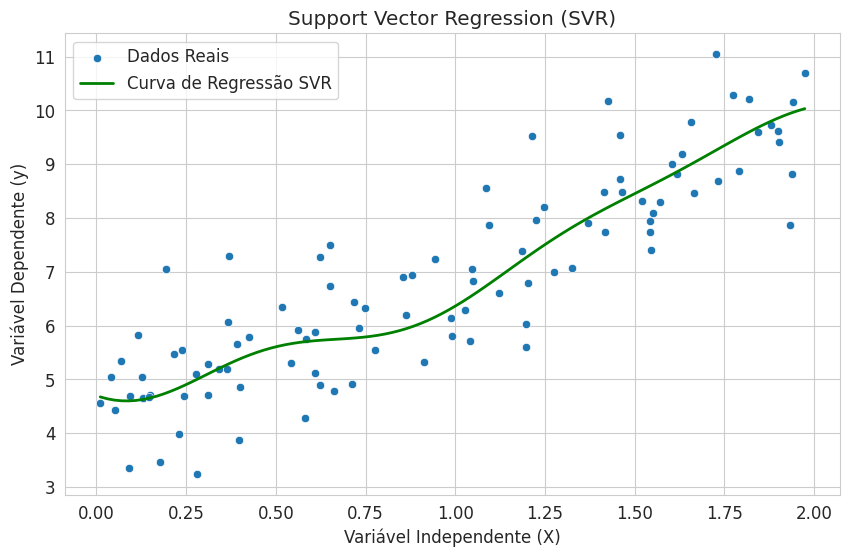

In [28]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Usaremos os dados de regressão linear simples (X, y) para demonstração

# Escalonamento das features é crucial para SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Dividir os dados escalonados
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_scaled, y_scaled.flatten(), test_size=0.2, random_state=42)

# --- Modelo SVR ---
# Kernel 'rbf' (Radial Basis Function) é comum para relações não-lineares
# C: Parâmetro de regularização (penalidade para pontos fora da margem)
# epsilon: Margem de erro permitida
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train_svr, y_train_svr)

y_pred_svr_scaled = svr_model.predict(X_test_svr)

# Inverter o escalonamento para obter as previsões na escala original
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test_svr.reshape(-1, 1))

mse_svr = mean_squared_error(y_test_original, y_pred_svr)
r2_svr = r2_score(y_test_original, y_pred_svr)

print("--- Support Vector Regression (SVR) ---")
print(f"MSE (SVR): {mse_svr:.2f}")
print(f"R-quadrado (SVR): {r2_svr:.2f}")

# Visualização (comparação com os dados originais)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X.flatten(), y=y.flatten(), label='Dados Reais')

# Plotar a linha de regressão SVR
X_new_svr_scaled = scaler_X.transform(np.linspace(X.min(), X.max(), 100).reshape(-1, 1))
y_new_pred_svr_scaled = svr_model.predict(X_new_svr_scaled)
y_new_pred_svr = scaler_y.inverse_transform(y_new_pred_svr_scaled.reshape(-1, 1))

plt.plot(np.linspace(X.min(), X.max(), 100), y_new_pred_svr, color='green', linewidth=2, label='Curva de Regressão SVR')
plt.title('Support Vector Regression (SVR)')
plt.xlabel('Variável Independente (X)')
plt.ylabel('Variável Dependente (y)')
plt.legend()
plt.show()

### 8.4. Métricas de Regressão

Avaliar o desempenho de um modelo de regressão é fundamental. As métricas quantificam o quão bem o modelo se ajusta aos dados. Aqui estão as mais comuns:

*   **Erro Quadrático Médio (MSE - Mean Squared Error)**:
    $$MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
    É a média dos quadrados dos erros (diferenças entre os valores reais e previstos). Penaliza erros maiores mais severamente. A unidade do MSE é o quadrado da unidade da variável dependente, o que pode dificultar a interpretabilidade.

*   **Raiz do Erro Quadrático Médio (RMSE - Root Mean Squared Error)**:
    $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
    É a raiz quadrada do MSE. Mais fácil de interpretar, pois tem a mesma unidade da variável dependente. Tanto MSE quanto RMSE são sensíveis a outliers.

*   **Erro Absoluto Médio (MAE - Mean Absolute Error)**:
    $$MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
    É a média dos valores absolutos dos erros. Menos sensível a outliers do que o MSE/RMSE, pois não eleva os erros ao quadrado. Tem a mesma unidade da variável dependente.

*   **R-quadrado (R² - Coefficient of Determination)**:
    $$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2} = 1 - \frac{MSE(modelo)}{Var(y)}$$
    Indica a proporção da variância na variável dependente que é explicada pelo modelo. Varia de 0 a 1 (para modelos que não se ajustam pior que a média), onde 1 indica que o modelo explica toda a variância e 0 indica que o modelo não explica nenhuma variância. Valores negativos podem ocorrer se o modelo for muito ruim. **Cuidado**: O R² sempre aumenta com a adição de mais variáveis independentes, mesmo que não sejam úteis.

*   **R-quadrado Ajustado (Adjusted R²)**:
    $$R_{adj}^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$
    Onde $n$ é o número de observações e $p$ é o número de preditores no modelo. O R-quadrado ajustado penaliza a adição de variáveis irrelevantes, tornando-o mais útil para comparar modelos com diferentes números de features. É sempre menor ou igual ao R².

In [29]:
from sklearn.metrics import mean_absolute_error

# Vamos usar os resultados do modelo de regressão linear simples para calcular todas as métricas
# y_test e y_pred_simple já foram calculados anteriormente

# MSE (já calculamos antes, mas vamos reforçar)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse) # Calculando RMSE
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

# Para R-quadrado Ajustado, precisamos do número de observações (n) e features (p)
n = len(y_test) # Número de observações no conjunto de teste
p = X_test.shape[1] # Número de features no conjunto de teste (para o modelo simples, p=1)

if p < n - 1: # Para evitar divisão por zero ou negativos
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = "N/A (p >= n-1)" # Não é possível calcular ou sem sentido

print("--- Métricas de Avaliação do Modelo Linear Simples ---")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-quadrado (R²): {r2:.2f}")
print(f"R-quadrado Ajustado: {adjusted_r2:.2f}")

--- Métricas de Avaliação do Modelo Linear Simples ---
MSE: 0.65
RMSE: 0.81
MAE: 0.59
R-quadrado (R²): 0.81
R-quadrado Ajustado: 0.80


### 9. Métodos Matemáticos Subjacentes

Cada tipo de regressão utiliza um método matemático fundamental para determinar os parâmetros (coeficientes) do modelo:

*   **Regressão Linear Simples e Múltipla**: O método padrão é o **Mínimos Quadrados Ordinários (MQO)**, ou em inglês, Ordinary Least Squares (OLS).
    *   **Objetivo**: Minimizar a soma dos quadrados das diferenças entre os valores observados ($y_i$) e os valores previstos pelo modelo ($\hat{y}_i$).
    *   **Matematicamente**: $\min \sum_{i=1}^n (y_i - (\beta_0 + \beta_1 X_{i1} + ... + \beta_p X_{ip}))^2$.
    *   **Solução**: Para regressão linear simples, $\beta_1 = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}$ e $\beta_0 = \bar{Y} - \beta_1 \bar{X}$. Para regressão linear múltipla, a solução é encontrada usando cálculo diferencial (derivando a função de custo em relação a cada coeficiente e igualando a zero) ou através de álgebra linear com a fórmula matricial $\beta = (X^T X)^{-1} X^T y$.

*   **Regressão Ridge**: Usa **Mínimos Quadrados com Penalidade L2**.
    *   **Objetivo**: Minimizar a soma dos quadrados dos resíduos (como OLS), mas adiciona uma penalidade que é proporcional ao quadrado da magnitude dos coeficientes.
    *   **Matematicamente**: $\min \left[ \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \beta_j^2 \right]$.
    *   **Solução**: Não possui uma forma fechada tão simples quanto OLS, mas pode ser resolvido eficientemente usando métodos iterativos ou, em álgebra linear, como $\beta = (X^T X + \alpha I)^{-1} X^T y$, onde $I$ é a matriz identidade.

*   **Regressão Lasso**: Usa **Mínimos Quadrados com Penalidade L1**.
    *   **Objetivo**: Similar ao Ridge, mas a penalidade é proporcional ao valor absoluto da magnitude dos coeficientes, o que permite que alguns coeficientes sejam exatamente zero (seleção de features).
    *   **Matematicamente**: $\min \left[ \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |\beta_j| \right]$.
    *   **Solução**: Não possui uma solução de forma fechada e é geralmente resolvido por métodos numéricos como o algoritmo de Gradiente Descendente Coordenado (Coordinate Descent).

*   **Support Vector Regression (SVR)**: O SVR baseia-se na otimização da **Função $\epsilon$-Insensível**.
    *   **Objetivo**: Encontrar um hiperplano que preveja os valores com um erro máximo $\epsilon$ (margem) e, ao mesmo tempo, minimize a complexidade do modelo (ou a norma dos pesos do vetor). Erros dentro da margem $\epsilon$ não são penalizados. Ele também pode usar o *kernel trick* para mapear os dados para um espaço de dimensão superior e modelar relações não-lineares.
    *   **Matematicamente**: O problema de otimização envolve encontrar $w$ e $b$ para minimizar $\frac{1}{2} ||w||^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$, sujeito a restrições como $y_i - w^T x_i - b \le \epsilon + \xi_i$ e $w^T x_i + b - y_i \le \epsilon + \xi_i^*$, onde $\xi_i, \xi_i^* \ge 0$ são variáveis de folga que medem a violação da margem e $C$ é o parâmetro de regularização.
    *   **Solução**: É resolvido como um problema de otimização convexa, tipicamente usando programação quadrática (Quadratic Programming).

## 10. Mínimos Quadrados Ordinários (MQO/OLS): Definição Formal, Tópicos Matemáticos e Aplicação

Os Mínimos Quadrados Ordinários (MQO), ou Ordinary Least Squares (OLS) em inglês, são o método padrão para estimar os coeficientes em modelos de regressão linear. Seu objetivo é encontrar a linha (ou hiperplano) que melhor se ajusta a um conjunto de dados, minimizando a soma dos quadrados dos resíduos.

### Definição Formal

Dado um conjunto de $n$ observações $(X_i, Y_i)$, onde $X_i$ pode ser um vetor de características para regressão múltipla, o objetivo do MQO é estimar os parâmetros do modelo $\beta = (\beta_0, \beta_1, ..., \beta_p)^T$ na equação:

$$Y_i = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + ... + \beta_p X_{ip} + \epsilon_i$$

Os estimadores de MQO $\hat{\beta}$ são aqueles que **minimizam a Soma dos Quadrados dos Resíduos (SSR)**:

$$SSR = \sum_{i=1}^n (Y_i - \hat{Y}_i)^2 = \sum_{i=1}^n (Y_i - (\hat{\beta}_0 + \hat{\beta}_1 X_{i1} + ... + \hat{\beta}_p X_{ip}))^2$$

Onde:
*   $Y_i$: Valor observado da variável dependente.
*   $\hat{Y}_i$: Valor previsto pelo modelo para a variável dependente.
*   $\hat{\beta}_j$: Coeficiente estimado para a $j$-ésima variável independente.
*   $p$: Número de variáveis independentes.

### Tópicos Matemáticos Relacionados

A compreensão do MQO envolve conceitos de diversas áreas da matemática:

*   **Otimização**: A essência do MQO é um problema de otimização irrestrita, onde buscamos o mínimo de uma função objetivo (a soma dos quadrados dos resíduos).
*   **Cálculo Diferencial**: Para encontrar o mínimo da função de custo, calculamos as derivadas parciais da função em relação a cada coeficiente ($\hat{\beta}_j$) e as igualamos a zero. Isso nos dá um sistema de equações lineares.
*   **Álgebra Linear**: O sistema de equações resultante pode ser resolvido de forma eficiente usando álgebra linear. A solução para os coeficientes $\hat{\beta}$ em forma matricial é dada por:

    $$\hat{\beta} = (X^T X)^{-1} X^T Y$$

    Onde $X$ é a matriz de design (contendo as variáveis independentes e uma coluna de uns para o intercepto) e $Y$ é o vetor da variável dependente.
*   **Estatística**: O MQO é um estimador estatístico. Propriedades como imparcialidade (unbiasedness), consistência e eficiência (sob certas condições, como o teorema de Gauss-Markov) são estudadas em inferência estatística.

### Exemplo Gráfico e Código

Você pode observar a aplicação do MQO nos exemplos práticos de Regressão Linear Simples e Múltipla neste notebook:

*   **Gráfico**: A visualização da **"Linha de Regressão Prevista"** no gráfico de Regressão Linear Simples (na seção **"4. Exemplo Prático: Regressão Linear Simples"**, especificamente no código da célula com ID `aeed384f`) é o resultado direto da aplicação do método de Mínimos Quadrados. Essa linha representa o melhor ajuste linear que minimiza os erros quadráticos.

*   **Código**: A implementação em Python do MQO é realizada pela biblioteca `statsmodels`. Na seção **"4. Exemplo Prático: Regressão Linear Simples"** (código na célula com ID `6aad5609`), o `statsmodels.api.OLS` é usado para ajustar o modelo. A saída detalhada (`results_sm.summary()`) fornece os coeficientes estimados (o resultado do MQO), seus erros padrão, p-valores e outras estatísticas importantes que derivam diretamente do processo de minimização dos quadrados dos resíduos.

## 11. Exemplos Clássicos de Aplicação da Regressão Linear

A regressão linear, apesar de sua simplicidade, é amplamente utilizada em diversas áreas devido à sua interpretabilidade e eficácia para modelar relações lineares. Alguns exemplos clássicos incluem:

1.  **Economia e Finanças**: Previsão de preços de ações, inflação, crescimento do PIB, demanda por produtos, salários com base em experiência e educação.
    *   **Exemplo**: Prever o preço de uma casa com base em características como área, número de quartos, localização, idade do imóvel, etc.
2.  **Marketing e Vendas**: Análise do impacto de gastos com publicidade em vendas, previsão de vendas futuras, determinação do preço ideal de produtos.
    *   **Exemplo**: Determinar quanto as vendas de um produto aumentarão para cada dólar adicional investido em uma campanha de marketing específica.
3.  **Saúde e Medicina**: Análise da relação entre dose de medicamento e resposta do paciente, fatores de risco para doenças, previsão de resultados de tratamentos.
    *   **Exemplo**: Investigar a relação entre a quantidade de um determinado nutriente na dieta e o nível de um biomarcador de saúde no sangue.
4.  **Engenharia**: Previsão da vida útil de componentes, otimização de processos de fabricação, análise de desempenho de materiais.
    *   **Exemplo**: Prever a resistência de um material com base em sua composição química e condições de processamento.
5.  **Ciências Sociais**: Estudo de relações entre variáveis sociais, como educação e renda, fatores que influenciam o voto, tendências demográficas.
    *   **Exemplo**: Analisar como o nível de escolaridade influencia o nível de renda de indivíduos em uma determinada região.

Em todos esses casos, o objetivo é entender e quantificar a relação entre variáveis para fazer previsões ou inferências.

## 12. Como Identificar se a Regressão Linear é o Modelo Ideal no Mercado?

A escolha do modelo ideal no mercado raramente se resume a uma única técnica e geralmente envolve uma abordagem multifacetada:

1.  **Entendimento do Problema e Dados (Domain Knowledge)**:
    *   Qual é o objetivo? Previsão, inferência, identificação de fatores-chave?
    *   Existe uma expectativa teórica ou empírica de uma relação linear entre as variáveis? O conhecimento do domínio é crucial aqui.
    *   Quais são as características dos dados (número de features, tamanho do dataset, linearidade aparente, presença de outliers)?

2.  **Análise Exploratória de Dados (EDA)**:
    *   **Gráficos de Dispersão**: Essenciais para visualizar a relação entre a variável dependente e cada variável independente. Se os pontos se agrupam em torno de uma linha reta, a regressão linear é uma boa candidata.
    *   **Correlações**: Calcular a matriz de correlação. Coeficientes de correlação de Pearson altos entre a variável dependente e as independentes sugerem relações lineares.
    *   **Distribuições**: Verificar a distribuição das variáveis. Variáveis independentes muito assimétricas podem precisar de transformação ou podem indicar que um modelo linear não é o mais adequado.

3.  **Verificação das Premissas da Regressão Linear**: Antes de confiar totalmente nos resultados, é fundamental verificar se as premissas são razoavelmente atendidas. Isso é feito principalmente após o ajuste do modelo:
    *   **Linearidade**: Observar gráficos de dispersão e gráficos de resíduos (resíduos vs. previstos) para padrões. Se houver um padrão curvo, um modelo não-linear (como regressão polinomial, SVR com kernel não-linear, ou outros) pode ser melhor.
    *   **Homocedasticidade**: Gráficos de resíduos vs. previstos. Se o espalhamento dos resíduos aumenta ou diminui com os valores previstos (formando um 'funil'), a premissa é violada.
    *   **Normalidade dos Resíduos**: Histogramas ou Q-Q plots dos resíduos. A violação pode impactar a validade dos testes de significância, mas é menos crítica para a capacidade preditiva do que a linearidade ou homocedasticidade.
    *   **Independência dos Resíduos**: Durbin-Watson statistic (para dados de séries temporais) ou inspeção de gráficos de resíduos. Autocorrelação nos resíduos (padrões nos gráficos de resíduos) sugere que o modelo não capturou toda a estrutura dos dados.
    *   **Ausência de Multicolinearidade**: Calcular VIFs (Variance Inflation Factors). VIFs altos indicam que features são altamente correlacionadas, o que pode tornar os coeficientes instáveis e difíceis de interpretar. Nesses casos, Ridge ou Lasso podem ser mais apropriados.

4.  **Comparação de Modelos e Métricas de Avaliação**: Ajuste vários modelos (linear, polinomial, Ridge, Lasso, SVR, modelos baseados em árvores, etc.) e compare-os usando:
    *   **Métricas de Desempenho**: RMSE, MAE, R² ajustado (para comparar modelos lineares com diferentes números de features). Para problemas de previsão, o foco é na capacidade preditiva em dados não vistos (usando conjuntos de validação e teste).
    *   **Validação Cruzada**: Fundamental para obter uma estimativa robusta do desempenho do modelo em dados novos e para comparar modelos de forma justa.

5.  **Interpretabilidade vs. Complexidade**: Se a interpretabilidade dos coeficientes é crucial (ex: em economia, medicina), a regressão linear é muitas vezes preferida, desde que suas premissas sejam razoavelmente atendidas. Se a precisão preditiva é a principal preocupação e a relação é complexa, modelos mais sofisticados podem ser necessários.

6.  **Benchmarking**: Começar com um modelo linear simples como baseline é uma boa prática. Se modelos mais complexos não oferecem uma melhoria significativa no desempenho preditivo, o modelo linear pode ser preferível pela sua simplicidade e interpretabilidade.

## 13. Diferença entre Regressão Linear e Análise de Fourier

Apesar de ambos serem ferramentas matemáticas poderosas, a Regressão Linear e a Análise de Fourier servem a propósitos fundamentalmente diferentes:

### Regressão Linear

*   **Propósito**: Modelar e entender a **relação entre variáveis**. Ela busca quantificar como uma ou mais variáveis independentes influenciam uma variável dependente.
*   **Foco**: Entender a **causalidade (ou associação)** e fazer **previsões** com base nessas relações.
*   **Tipo de Dados**: Geralmente usada com dados onde se espera uma relação funcional entre as características (features) e um alvo contínuo. Não é exclusiva para séries temporais, mas pode ser aplicada a elas para prever um valor futuro com base em características do presente ou passado.
*   **Saída**: Um conjunto de coeficientes que descrevem a magnitude e a direção do impacto de cada variável independente na variável dependente.
*   **Exemplo**: Prever o preço de um carro com base na sua idade, quilometragem e marca. O resultado é um modelo que diz, por exemplo, que para cada ano a mais, o carro perde X reais de valor.

### Análise de Fourier (Transformada de Fourier)

*   **Propósito**: Decompor uma **função ou sinal** em suas **frequências constituintes**. Ela revela quais frequências estão presentes em um sinal e a magnitude de cada uma.
*   **Foco**: Análise de **padrões de frequência, periodicidade, ruído** e características ocultas em sinais, especialmente séries temporais.
*   **Tipo de Dados**: Predominantemente aplicada a **séries temporais** ou sinais contínuos (como áudio, imagens) onde a estrutura temporal ou espacial é importante e se busca identificar ciclos ou componentes harmônicos.
*   **Saída**: Um espectro de frequências, mostrando a amplitude e fase de cada componente de frequência no sinal original.
*   **Exemplo**: Analisar um sinal de áudio para identificar as notas musicais presentes (frequências) ou um registro de vendas diárias para identificar padrões sazonais anuais ou mensais (ciclos de frequência). O resultado é uma representação do sinal no domínio da frequência.

### Analogia Simplificada

Imagine que você tem uma música:

*   A **Regressão Linear** seria como tentar prever a popularidade da música com base em características como o tempo de duração, o gênero ou o número de palavras cantadas. Você está relacionando características para prever um resultado.
*   A **Análise de Fourier** seria como ouvir a música e decompor ela nos seus instrumentos individuais, nas frequências das batidas, da melodia, dos vocais. Você está entendendo a composição interna do sinal em termos de suas frequências.

Em resumo, a regressão linear modela *relações entre variáveis*, enquanto a análise de Fourier *desvenda a estrutura de frequência de um sinal*.